In [1]:
import psutil
import time
import threading
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
sys.path.append('..')

In [2]:
from utils.monitor_ram import monitor_ram
from utils.monitor_cpu import monitor_cpu

In [3]:
from scarf import scarf

Scarf is not installed


# DS

In [4]:
ds_8k = scarf.DataStore('../data/baron_8K_pancreas_rnaseq.zarr')
ds_14k = scarf.DataStore('../data/kang_14K_ifnb-pbmc_rnaseq.zarr')
ds_15k = scarf.DataStore('../data/kang_15K_pbmc_rnaseq.zarr')
ds_69k = scarf.DataStore('../data/zheng_69K_pbmc_rnaseq.zarr')
ds_783k = scarf.DataStore('../data/hca_783K_blood_rnaseq.zarr')
ds_1_3m = scarf.DataStore('../data/tenx_1.3M_brain_rnaseq.zarr')
ds_merged = scarf.DataStore('../data/kang_merged_14k_15k.zarr')

In [5]:
def create_random_values(n,classes=2,seed=42):
    rng = np.random.default_rng(seed=seed)
    return rng.integers(0,classes,n)

create_random_values(10,2)

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0])

In [21]:
ds_8k.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_8k.cells.N,classes=2),
    overwrite=True
)

ds_14k.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_14k.cells.N,classes=2),
    overwrite=True
)

ds_15k.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_15k.cells.N,classes=2),
    overwrite=True
)

ds_69k.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_69k.cells.N,classes=2),
    overwrite=True
)

ds_783k.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_783k.cells.N,classes=2),
    overwrite=True
)

ds_1_3m.cells.insert(
    column_name='sample_id',
    values=create_random_values(ds_1_3m.cells.N,classes=2),
    overwrite=True
)

In [8]:
def plot_ram(ram_vals):
    # ram_vals is a list of RAM values at each 1 second interval
    plt.figure(figsize=(5, 2.5))
    plt.plot(ram_vals)
    # add red dots at each point
    plt.scatter(range(len(ram_vals)), ram_vals, c='red')
    plt.xlabel('Time (s)')
    plt.ylabel('RAM (GB)')
    plt.title('RAM usage for merged dataset')
    plt.show()

# LISI

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

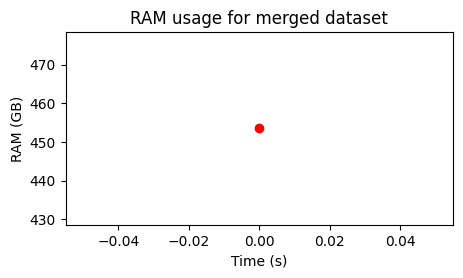

In [27]:
ram_8k = monitor_ram(
    ds_8k.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_8k)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

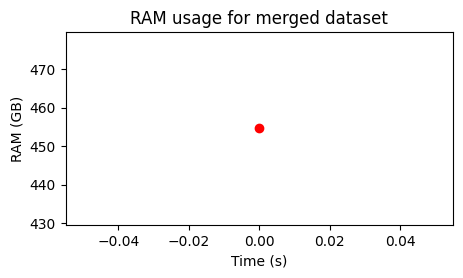

In [28]:
ram_14k = monitor_ram(
    ds_14k.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_14k)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

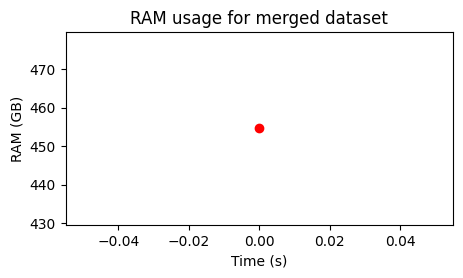

In [30]:
ram_15k = monitor_ram(
    ds_15k.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_15k)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

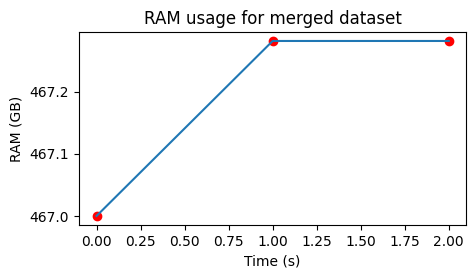

In [32]:
ram_69k = monitor_ram(
    ds_69k.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_69k)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

/media/chs.gpu/nygen/scarf-metrics/benchmark/../scarf/scarf/metrics.py:66: RuntimeWarning: divide by zero encountered in divide
  lisi_df[:, i] = 1 / simpson


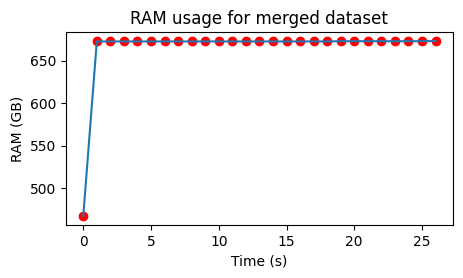

In [33]:
ram_783k = monitor_ram(
    ds_783k.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_783k)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

/media/chs.gpu/nygen/scarf-metrics/benchmark/../scarf/scarf/metrics.py:66: RuntimeWarning: divide by zero encountered in divide
  lisi_df[:, i] = 1 / simpson


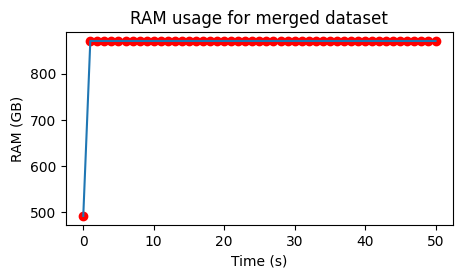

In [34]:
ram_1_3m = monitor_ram(
    ds_1_3m.metric_lisi,
    ['sample_id']    
)
plot_ram(ram_1_3m)

INFO: Using default assay for KNN graph.
INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21
INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

/media/chs.gpu/nygen/scarf-metrics/benchmark/../scarf/scarf/metrics.py:66: RuntimeWarning: divide by zero encountered in divide
  lisi_df[:, i] = 1 / simpson


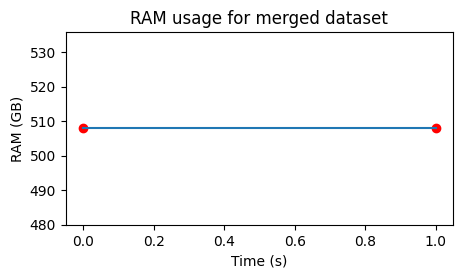

In [35]:
ram_merged = monitor_ram(
    ds_merged.metric_lisi,
    ['sample_id']
)
plot_ram(ram_merged)

# Silhouette

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

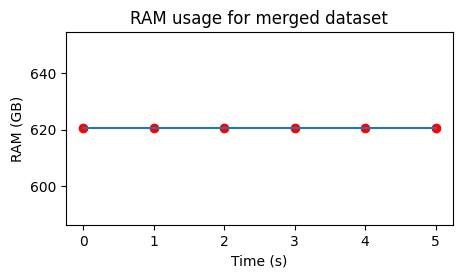

In [37]:
ram_silhouette_8k = monitor_ram(
    ds_8k.metric_silhouette,
)
plot_ram(ram_silhouette_8k)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

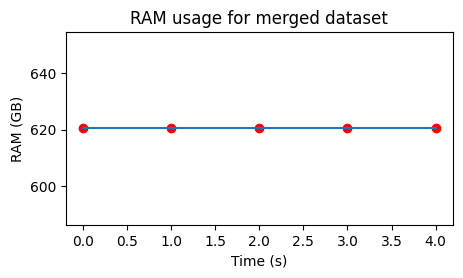

In [38]:
ram_silhouette_14k = monitor_ram(
    ds_14k.metric_silhouette,
)
plot_ram(ram_silhouette_14k)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

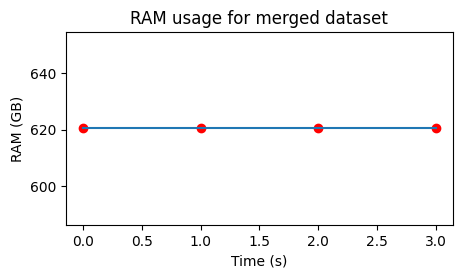

In [39]:
ram_silhouette_15k = monitor_ram(
    ds_15k.metric_silhouette,
)
plot_ram(ram_silhouette_15k)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

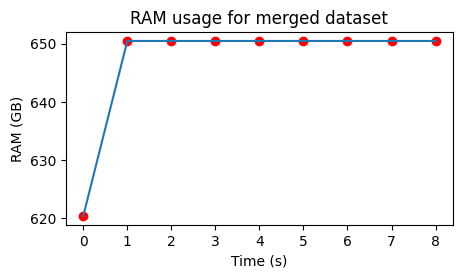

In [40]:
ram_silhouette_69k = monitor_ram(
    ds_69k.metric_silhouette,
)
plot_ram(ram_silhouette_69k)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

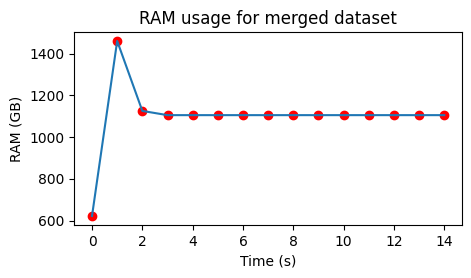

In [41]:
ram_silhouette_783k = monitor_ram(
    ds_783k.metric_silhouette,
)
plot_ram(ram_silhouette_783k)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

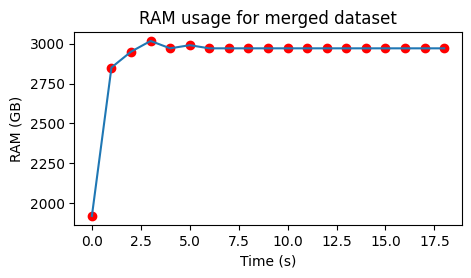

In [9]:
ram_silhouette_1_3m = monitor_ram(
    ds_1_3m.metric_silhouette,
)
plot_ram(ram_silhouette_1_3m)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__63__63__48__4466/knn__21 for assay: RNA
INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 25 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


Calculating Silhouette Scores:   0%|                                                                          …

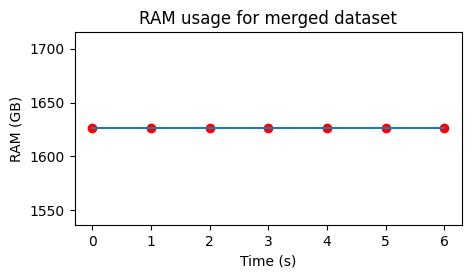

In [43]:
ram_silhouette_merged = monitor_ram(
    ds_merged.metric_silhouette,
)
plot_ram(ram_silhouette_merged)

# ARI

In [53]:
ds_8k.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_8k.cells.N,classes=len(np.unique(ds_8k.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_14k.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_14k.cells.N,classes=len(np.unique(ds_14k.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_15k.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_15k.cells.N,classes=len(np.unique(ds_15k.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_69k.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_69k.cells.N,classes=len(np.unique(ds_69k.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_783k.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_783k.cells.N,classes=len(np.unique(ds_783k.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_1_3m.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_1_3m.cells.N,classes=len(np.unique(ds_1_3m.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

ds_merged.cells.insert(
    column_name='RNA_leiden_cluster_random',
    values=create_random_values(ds_merged.cells.N,classes=len(np.unique(ds_merged.cells.fetch_all('RNA_leiden_cluster')))),
    overwrite=True
)

In [56]:
ds_8k.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-0.000195293816755071

In [57]:
ds_14k.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-9.908868965163112e-05

In [58]:
ds_15k.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-7.297974952384359e-05

In [59]:
ds_69k.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

7.0235289352483045e-06

In [60]:
ds_783k.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-2.1387384240040852e-06

In [61]:
ds_1_3m.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-7.733839634880283e-07

In [62]:
ds_merged.metric_integration(
    batch_labels=['RNA_leiden_cluster', 'RNA_leiden_cluster_random'],
    metric='ari'
)

-5.53501337764619e-05